## Use GPU to speedup SHAP value computation

In [1]:
import shap
from sklearn.datasets import fetch_california_housing
import xgboost as xgb
from sklearn import datasets


In [45]:
shap.initjs()

### Fetch dataset using sklearn

In [2]:
data = fetch_california_housing()

In [3]:
# print(data.DESCR)
X = data.data
y = data.target

num_round = 500

In [4]:
param = {
    "eta": 0.05,
    "max_depth": 10,
    "tree_method": "hist",
    "device": "cuda",
}

In [5]:
# GPU accelerated training
dtrain = xgb.DMatrix(X, label=y, feature_names=data.feature_names)
model = xgb.train(param, dtrain, num_round)

# Compute shap values using GPU with xgboost

In [44]:

model.set_param({"device": "cuda"})
shap_values = model.predict(dtrain, pred_contribs=True)
shap_interaction_values = model.predict(dtrain, pred_interactions=True)

In [6]:
# shap will call the GPU accelerated version as long as the device parameter is set to
# "cuda"
explainer = shap.TreeExplainer(model,feature_names=data.feature_names)

explainer_values = explainer(X,check_additivity=False)
shap_values = explainer_values.values
shap_interaction_values = explainer.shap_interaction_values(X)
except_value = explainer.expected_value

### 1. 全局特征贡献总览

* 图表类型：SHAP Summary Plot（摘要图）
* 用途：
* 展示所有特征对模型预测的总体影响方向（正向/负向）及重要性排序
* 识别高影响力特征与数据分布的关系

* 解读要点：
  * X轴：SHAP值（贡献度大小）
  * Y轴：特征重要性排名
  * 颜色：特征值高低（红=高，蓝=低）

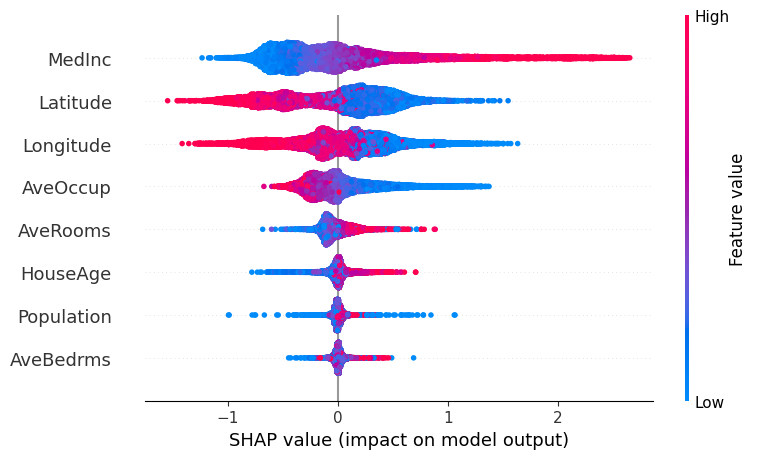

In [51]:
shap.summary_plot(shap_values,X,plot_type='dot',max_display=10,feature_names=data.feature_names )

### 2. 单样本决策路径解析
* 图表类型：Force Plot（力图） / Waterfall Plot（瀑布图）
* 用途：
* 解释单个预测结果的驱动因素（如某患者被诊断为糖尿病的核心特征）
* 显示特征贡献的叠加过程（基础值 → 最终预测值）

* 解读要点：
  * 红色箭头：提升预测值的特征（如血糖值过高）
  * 蓝色箭头：降低预测值的特征（如年龄较低）
  * Base Value：数据集的平均预测基准

In [7]:
# 单样本力图  
shap.force_plot(
    explainer.expected_value,
    shap_values[0,:],
    X[0, :],
    feature_names=data.feature_names,

)

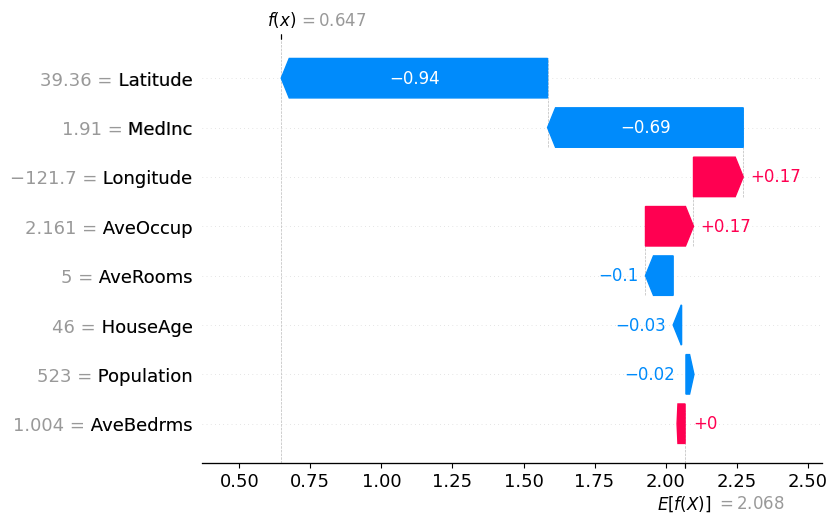

In [55]:
# 瀑布图  
# 创建Explanation对象
# explanation = shap.Explanation(values=shap_values, base_values=except_value, data=X,feature_names=data.feature_names)
shap.plots.waterfall(explainer_values[1200])

In [ ]:
# visualize the first prediction's explanation


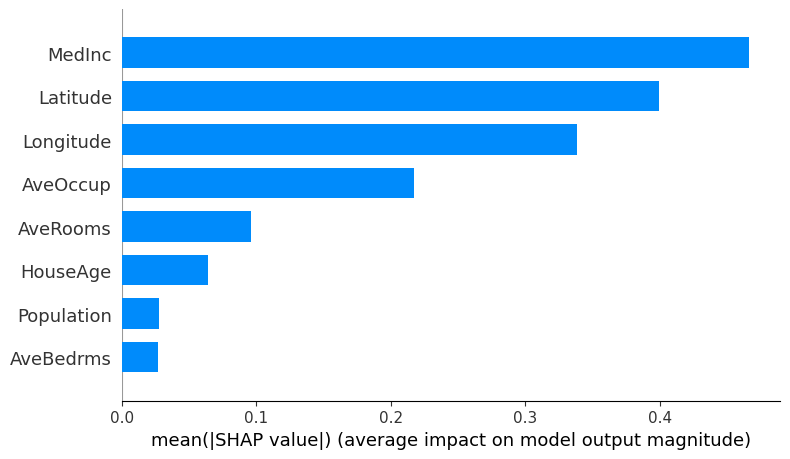

In [56]:
# Show a summary of feature importance
shap.summary_plot(shap_values, X, plot_type="bar", feature_names=data.feature_names)

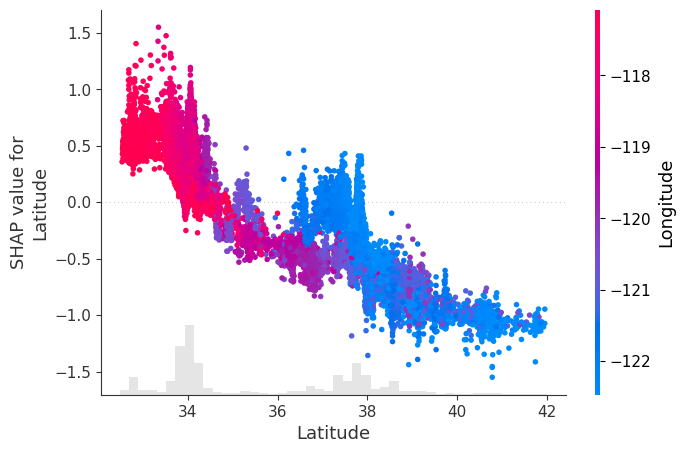

In [57]:
# create a dependence scatter plot to show the effect of a single feature across the whole dataset
shap.plots.scatter(explainer_values[:,'Latitude'], color=explainer_values)

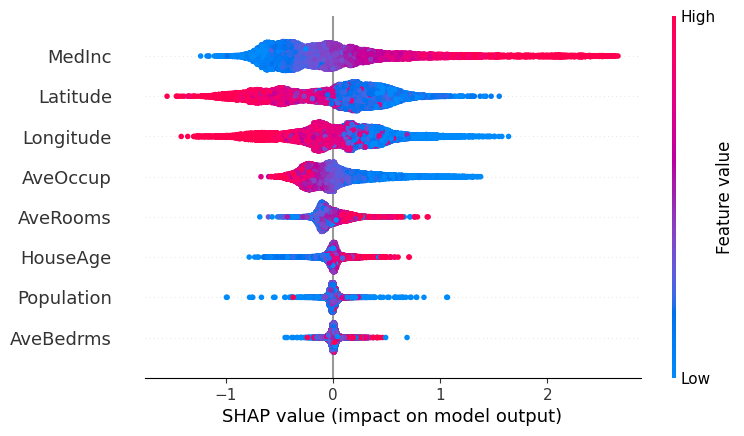

In [47]:
shap.plots.beeswarm(explainer_values)

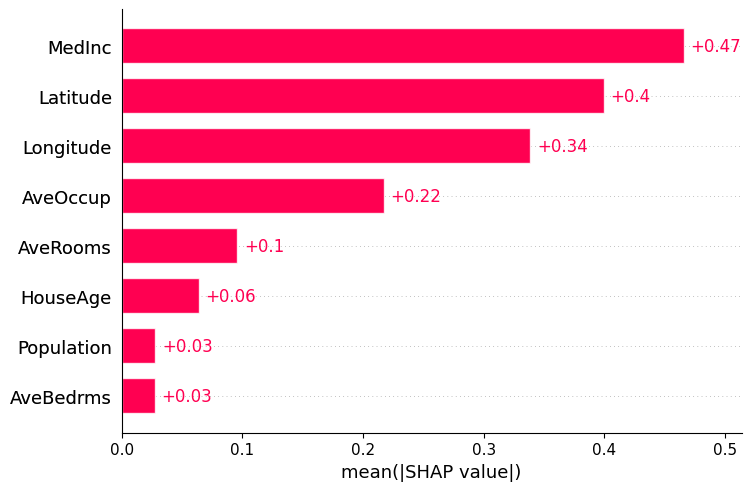

In [58]:
shap.plots.bar(explainer_values)

In [ ]:
explainer_values.data.